In [128]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Lectura del dataset. 
En el dataset original, los nombres de las columnas tienen espacios inecesarios al inicio y al final. Esta celda recupera el dataset y elimina esos espacios incomodos. Si la cadena resultante es vacía, coloca un simbolo "-" para indicar la ausencia de un valor para esa columna

In [129]:
# pd.set_option('display.max_rows', 200)   # show up to 200 rows
df = pd.read_csv("fm2023.csv")

s=df.columns
a=s.tolist()
for i in range(len(a)):
    a[i]=a[i].strip()
df.columns=a
df.columns

Index(['UID', 'Inf', 'Name', 'DoB', 'Nat', 'Division', 'Club', 'Based',
       'Preferred Foot', 'Right Foot', 'Left Foot', 'Position', 'Height',
       'Weight', 'Age', 'Transfer Value', 'Wage', 'AT Apps', 'AT Gls', 'Team',
       'Caps', 'Yth Apps', 'Style', 'Rc Injury', 'Best Role', 'Best Duty',
       'Best Pos', 'Acc', 'Aer', 'Agg', 'Agi', 'Ant', 'Bal', 'Bra', 'Cmd',
       'Com', 'Cmp', 'Cnt', 'Cor', 'Cro', 'Dec', 'Det', 'Dri', 'Ecc', 'Fin',
       'Fir', 'Fla', 'Fre', 'Han', 'Hea', 'Jum', 'Kic', 'Ldr', 'Lon', 'L Th',
       'Mar', 'Nat .1', 'OtB', '1v1', 'Pac', 'Pas', 'Pen', 'Pos', 'Pun', 'Ref',
       'TRO', 'Sta', 'Str', 'Tck', 'Tea', 'Tec', 'Thr', 'Vis', 'Wor'],
      dtype='object')

In [130]:
import numpy as np

def clean_strings(df):
    df = df.copy()
    
    string_cols = df.select_dtypes(include=["object", "string"]).columns
    
    for col in string_cols:
        df[col] = (
            df[col]
            .str.strip()
            .replace("", "-")
        )
    
    return df

In [131]:
df = clean_strings(df)

In [132]:
df.dtypes

UID      int64
Inf     object
Name    object
DoB     object
Nat     object
         ...  
Tea      int64
Tec      int64
Thr      int64
Vis      int64
Wor      int64
Length: 74, dtype: object

# Limpieza

## Conversión de Transfer Value de rangos de precio -> un precio fijo
La columna "Transfer Value" de nuestro dataset contiene rangos de precios a los que los clubes estarían dispuestos a vender a un jugador.
Para trabajar con el valor de transferencia como un número y no un rango, el siguiente par de celdas:
- 1) Recuperan tanto el valor mínimo (min_price) como el máximo (max_price) de cada jugador.
- 2) Crean una nueva columna llamada "transfer_value_estimado" que contiene la siguiente estimación de valor de transferencia:
    $\frac{\text{max\_price} + \text{min\_price}}{2}$ que no es otra cosa más que el punto medio.
    La nueva columna contiene valores numéricos que representan el valor de transferencia estimado en euros (sin abreviaciones).

### Consideraciones
Algunos jugadores poseen un estatus particular respecto a su valor de transferencia. Por un lado, algunos no tienen club, por lo que su valor de transferencia es 0. Por otro lado, algunos jugadores son considerados como clave dentro de sus equipos. Esta consideración hace que los clubes no estén dispuestos a negociar con ningún otro club la venta de tal jugador. Para estos segundos, el juego, en lugar de asignar un rango de precios, le asigna un texto que dice "NotforSale". Para estos casos, y con el objetivo de que todos los jugadores tengan un precio asociado, se les asignó un precio arbitrariamente alto (100 millones de euros) para representar que ninguna oferta satisfará al club.

EL siguiente par de celdas:
- 1) Crean la función que genera la nueva columna
- 2) Aplican la función a nuestro dataset

In [133]:
inf_price=1000e6
def parse_euro_value(s: str) -> float:
    if(s=="NotforSale"):
        return float(inf_price)

    try:
        i = s.index("-")  
        x = s[i+1:]    
    except:
        x=s
    
    x = x.replace("€", "").strip()

    if x.endswith("K"):
        return float(x[:-1]) * 1e3
    elif x.endswith("M"):
        return float(x[:-1]) * 1e6
    else:
        return float(x)

def range_average(range_str: str) -> int:
    try:
        low, high = range_str.split("-")        
    except:
        low, high = range_str,range_str
        
    low_val = parse_euro_value(low)
    high_val = parse_euro_value(high)

    return int((low_val + high_val) / 2)


def genera_columna_precios(df):
    df["Transfer Value"] = (
    df["Transfer Value"]
        .astype(str)
        .str.replace(" ", "", regex=False)
        .str.replace("€", "", regex=False)
    )
    df["transfer_value_estimado"] = df["Transfer Value"].apply(range_average)
    # df.drop("Transfer Value")
    return df

In [134]:
df=genera_columna_precios(df)

## Cantidad y eliminación de registros duplicados
Hay un total de 93 jugadores con registros duplicados en el conjunto de datos. Cada uno de esos 93 jugadores aparece 2 veces en el conjunto. Podemos eliminarlos dado que la cantidad es relativamente pequeña.

In [135]:
print("Registros duplicados:",df[df.duplicated()].shape[0])
df_no_dups=df.drop_duplicates()
print("Con duplicados",df.shape)
print("Sin duplicados",df_no_dups.shape)

Registros duplicados: 93
Con duplicados (189345, 75)
Sin duplicados (189252, 75)


## Conversión AT Gls y AT Apps a enteros

In [136]:

df["AT Gls"]=df["AT Gls"].replace('-', 0)
df["AT Apps"]=df["AT Apps"].replace('-', 0)


df["AT Apps"]=df["AT Apps"].astype(np.int64)
df["AT Gls"]=df["AT Gls"].astype(np.int64)


In [137]:
numericos=[]
for col in df.columns:
    if df[col].dtypes=="int64" and df[col].min()>=0 and df[col].max()<=20:
        numericos.append(col)

## Sustitución de valores "-" por 0 en columnas de caracter numerico

In [138]:
cols_with_dash = df.columns[(df == "-").any()]
print(cols_with_dash.tolist())

['Inf', 'Division', 'Club', 'Wage', 'Team', 'Yth Apps', 'Rc Injury']


In [139]:
numeric=['Wage', 'AT Apps', 'AT Gls', 'Yth Apps']
# categoric=['Inf','Division', 'Club','Team', 'Rc Injury']   
df[numeric] = (
    df[numeric]
        .replace("-", 0)
)


## Conversión Yth Apps a entero

In [140]:
df["Yth Apps"] = pd.to_numeric(df["Yth Apps"], errors="coerce").fillna(0).astype(int)

## Conversión de wage a un número entero

In [141]:
df["Wage"] = (
    df["Wage"]
        .replace(["N/A", 0], "0")                # normalize N/A and 0
        .astype(str)                             # ensure string
        .str.replace("€", "", regex=False)       # remove €
        .str.replace(",", "", regex=False)       # remove commas
        .str.replace(" p/m", "", regex=False)    # remove p/m
        .str.strip()                             # remove spaces
)

df["Wage"] = pd.to_numeric(df["Wage"], errors="coerce").fillna(0).astype(int)

## Conversión altura y peso a números enteros

In [142]:
df["Height"] = (
    df["Height"]
    .str.replace("cm", "", regex=False)
    .str.strip()
    .astype(int)
)
df["Weight"] = (
    df["Weight"]
    .str.replace("kg", "", regex=False)
    .str.strip()
    .astype(int)
)

## Almacenamos dataset como npz con las columnas relevantes
Solamente ignoramos UID, Inf y DoB (la primera es un id, la segunda no se y la tercera la fecha de nacimiento, que nos es irrelevante por que ya hay otra columna que menciona la edad)

In [143]:
cols=[ 'Nat', 'Division', 'Club', 'Based',
       'Preferred Foot', 'Right Foot', 'Left Foot', 'Position', 'Height',
       'Weight', 'Age', 'Wage', 'AT Apps', 'AT Gls', 'Team',
       'Caps', 'Yth Apps', 'Style', 'Rc Injury', 'Best Role', 'Best Duty',
       'Best Pos', 'Acc', 'Aer', 'Agg', 'Agi', 'Ant', 'Bal', 'Bra', 'Cmd',
       'Com', 'Cmp', 'Cnt', 'Cor', 'Cro', 'Dec', 'Det', 'Dri', 'Ecc', 'Fin',
       'Fir', 'Fla', 'Fre', 'Han', 'Hea', 'Jum', 'Kic', 'Ldr', 'Lon', 'L Th',
       'Mar', 'Nat .1', 'OtB', '1v1', 'Pac', 'Pas', 'Pen', 'Pos', 'Pun', 'Ref',
       'TRO', 'Sta', 'Str', 'Tck', 'Tea', 'Tec', 'Thr', 'Vis', 'Wor',
       'transfer_value_estimado']


df_save=df[cols]
df_save.to_pickle("data_set_limpio.pkl")

## Almacenar dataset sin considerar a los jugadores notforsale

In [144]:

# threshold = 9.4e3
threshold = inf_price
df_sin_not_for_sale=df[df['transfer_value_estimado'] < threshold]
df_save=df_sin_not_for_sale[cols]
df_save.to_pickle("data_set_limpio_sin_not_for_sale.pkl")

# Crear archivos txt de valores por atributo
Para poder visualizar los tipos de datos e identificar registros "vacios" pero que no son explicitamente un NaN o un Null (por ejemplo, un string = " - "), esta celda crea, para cada atributo, un archivo txt donde escribe en cada linea los distintos valores que se encuentran en todo el dataset para ese atributo.
> **CUIDADO:** Ejecutar esta celda generará 74 archivos .txt

In [145]:
nombre_carpeta = "valores_posibles_por_atributo"
generar=False
if generar:
    # Create folder if it doesn't exist
    os.makedirs(nombre_carpeta, exist_ok=True)

    for col in df.columns:
        values = sorted(df[col].unique())

        with open(f"{nombre_carpeta}/{col}.txt", "w") as f:
            for v in values:
                f.write(str(v) + "\n")

# Gráficas y EDA

## Cantidad de jugadores por nacionalidad

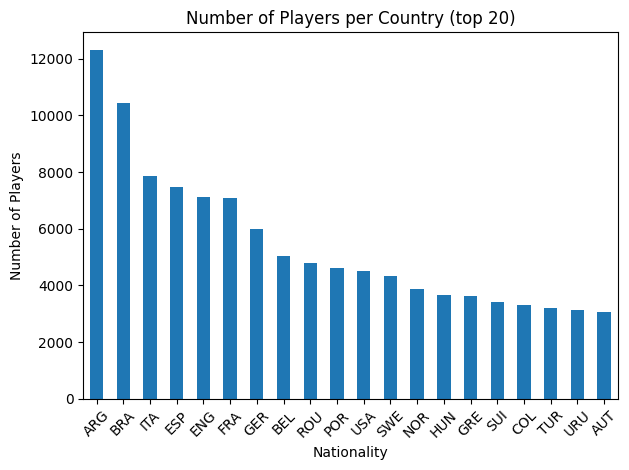

In [146]:
top_cantidad=20
counts = df["Nat"].value_counts()
counts = counts.head(20)
 

plt.figure()
counts.plot(kind="bar")

plt.title(f"Number of Players per Country (top {top_cantidad})")
plt.xlabel("Nationality")
plt.ylabel("Number of Players")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cantidad de jugadores por posición

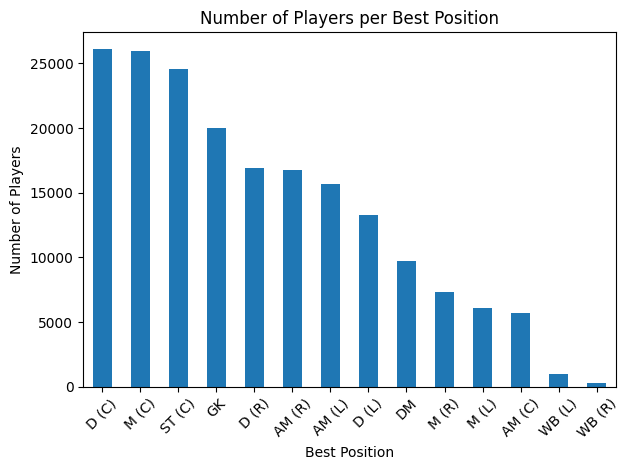

In [147]:
counts = df["Best Pos"].value_counts()
counts = counts.head(50)

plt.figure()
counts.plot(kind="bar")

plt.title("Number of Players per Best Position")
plt.xlabel("Best Position")
plt.ylabel("Number of Players")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Proporción de jugadores con valor de transferencia mayor que un umbral

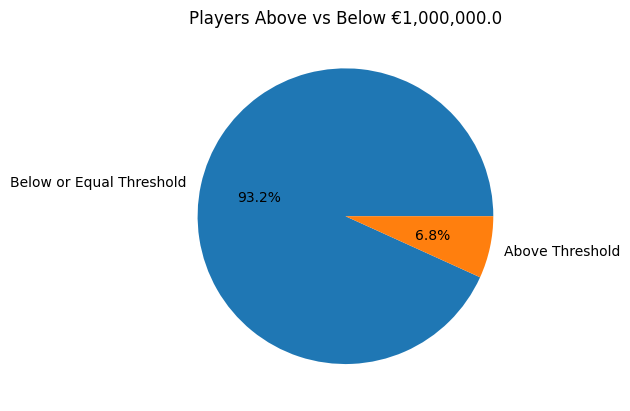

In [148]:
# threshold = 9.4e3 # este separa al dataset en 50% y 50%
threshold = 1e6

df["price_group"] = np.where(
    df["transfer_value_estimado"] > threshold,
    "Above Threshold",
    "Below or Equal Threshold"
)

counts = df["price_group"].value_counts()

plt.figure()
plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.title(f"Players Above vs Below €{threshold:,}")
plt.show()

## Cantidad de jugadores por edad

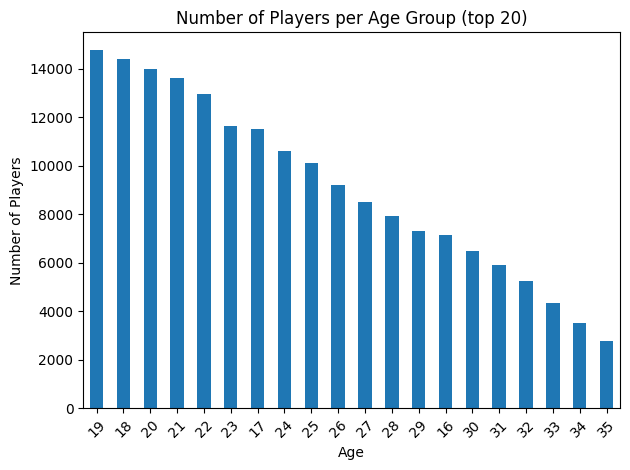

In [149]:
top_cantidad=20
counts = df["Age"].value_counts()
counts = counts.head(top_cantidad)
 

plt.figure()
counts.plot(kind="bar")

plt.title(f"Number of Players per Age Group (top {top_cantidad})")
plt.xlabel("Age")
plt.ylabel("Number of Players")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cantidad de jugadores por estilo de juego

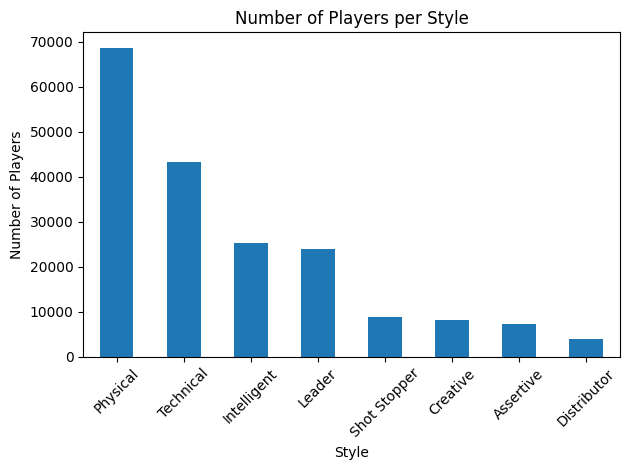

In [150]:
counts = df["Style"].value_counts()
counts = counts.head(20)
 
plt.figure()
counts.plot(kind="bar")

plt.title("Number of Players per Style")
plt.xlabel("Style")
plt.ylabel("Number of Players")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Jugadores not for sale
Algunos jugadores tienen en su valor de transferencia la frase "NotforSale" que indica que el club con el que tiene contrato no esta dispuesto a negociar la salida del jugador. Para representar este caso en la columna transfer_value_estimado, se colocó un precio fijo llamano inf_price que es igual a 100 millones de euros. Este alto costo representa esa indisposición de los equipos a vender a tal jugador.

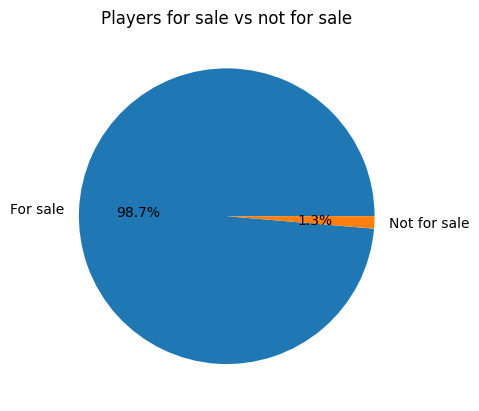

In [151]:

# threshold = 9.4e3
threshold = inf_price

df["notforsale_count"] = np.where(
    df["transfer_value_estimado"] >= threshold,
    "Not for sale",
    "For sale"
)

counts = df["notforsale_count"].value_counts()

plt.figure()
plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.title(f"Players for sale vs not for sale")
plt.show()

## Cuantos jugadores tienen al menos 1 columna con valor vació ("-")

In [152]:
def count_missing_at_least_one(df, columns=None):
    """
    Cuenta cuantos renglones del dataframe tienen al menos un "-" en alguna de las columnas especificadas
    """
    if columns is None:
        columns = df.columns
    
    return (df[columns] == "-").any(axis=1).sum()

## Columnas con almenos un jugador que tiene esa columna vacía

In [153]:
for col in df.columns:
    val=count_missing_at_least_one(df,[col])
    if val>0:
        print(col,":",val)

Inf : 101147
Division : 29667
Club : 28245
Team : 181502
Rc Injury : 187170


## Distribución por edad

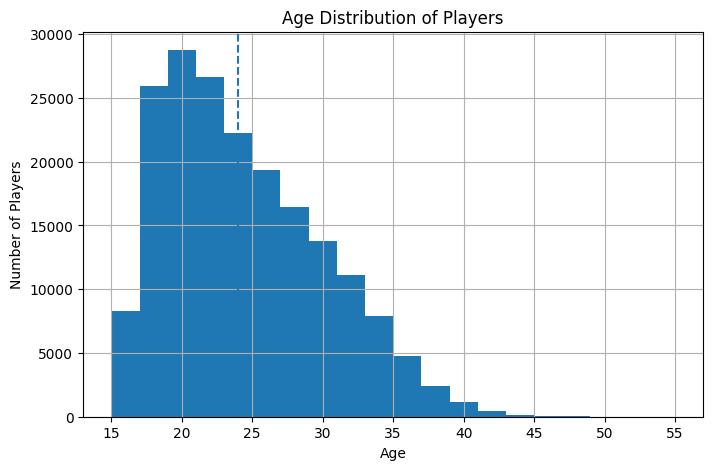

In [154]:
plt.figure(figsize=(8,5))

df["Age"].hist(bins=20)

mean_age = df["Age"].mean()
plt.axvline(mean_age, linestyle="--")

plt.title("Age Distribution of Players")
plt.xlabel("Age")
plt.ylabel("Number of Players")

plt.show()

## Distribución por transfer value

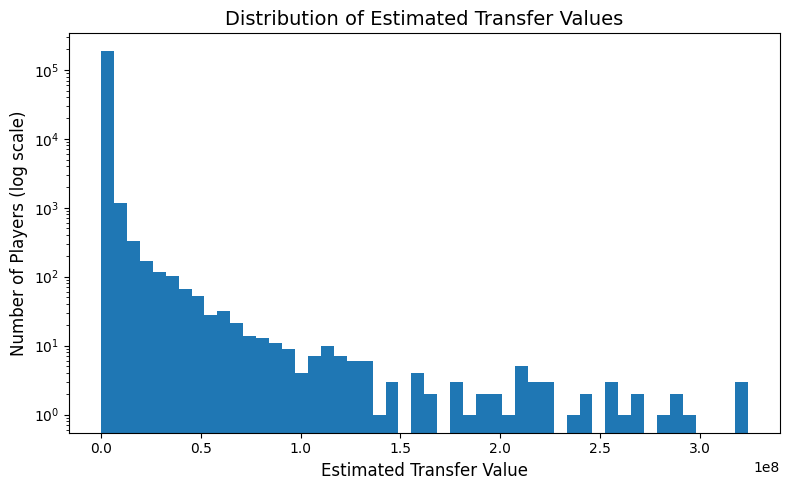

In [155]:
df2=df[df["notforsale_count"]=="For sale"]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df2["transfer_value_estimado"], bins=50)
plt.yscale("log")

plt.title("Distribution of Estimated Transfer Values", fontsize=14)
plt.xlabel("Estimated Transfer Value", fontsize=12)
plt.ylabel("Number of Players (log scale)", fontsize=12)

plt.tight_layout()
plt.show()

## Edad vs transfer value

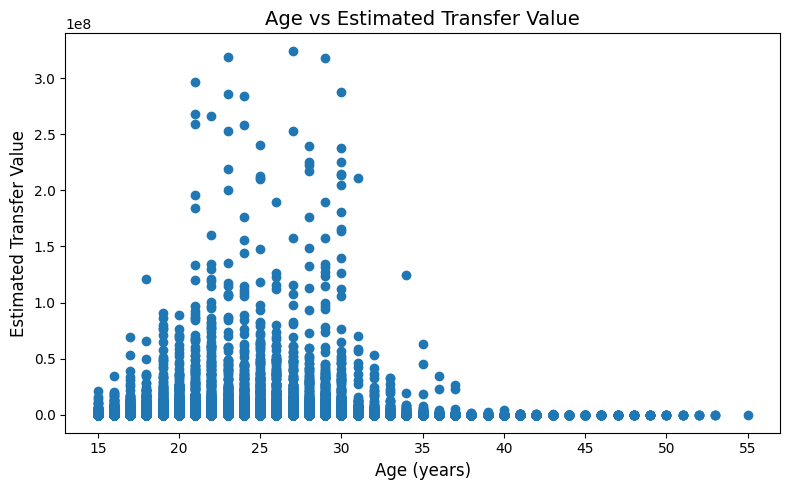

In [156]:
df2=df[df["notforsale_count"]=="For sale"]
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df2["Age"], df2["transfer_value_estimado"])

plt.title("Age vs Estimated Transfer Value", fontsize=14)
plt.xlabel("Age (years)", fontsize=12)
plt.ylabel("Estimated Transfer Value", fontsize=12)

plt.tight_layout()
plt.show()

## Distribución por liga

In [157]:
df["Division"].value_counts().head(10)

Division
-                                    29667
Argentine Premier Division            2369
Argentine Second Division             2138
Italian Serie A                       1761
Argentine Torneo Federal C            1603
Sky Bet Championship                  1546
Italian Serie B                       1537
Brazilian National First Division     1441
English Premier Division              1350
Brazilian National Lower Division     1331
Name: count, dtype: int64

## Correlación entre variables

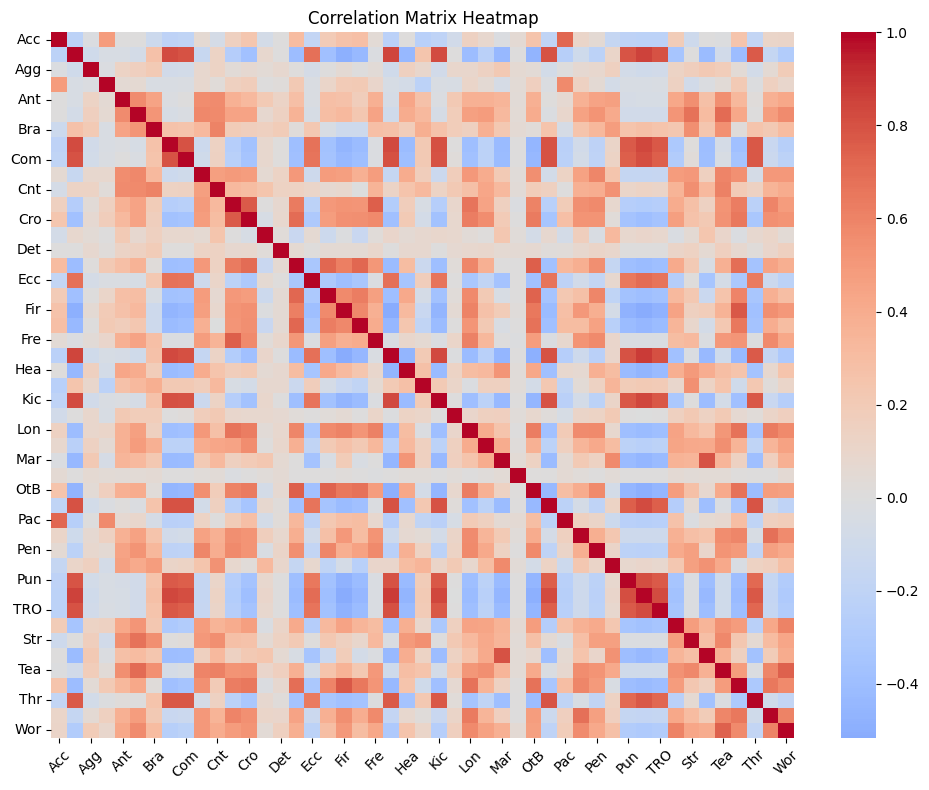

In [158]:
subset = df[numericos]
corr = subset.corr(numeric_only=True)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=False,
    fmt=".2f",
    cmap="coolwarm",       
    center=0
)

plt.title("Correlation Matrix Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

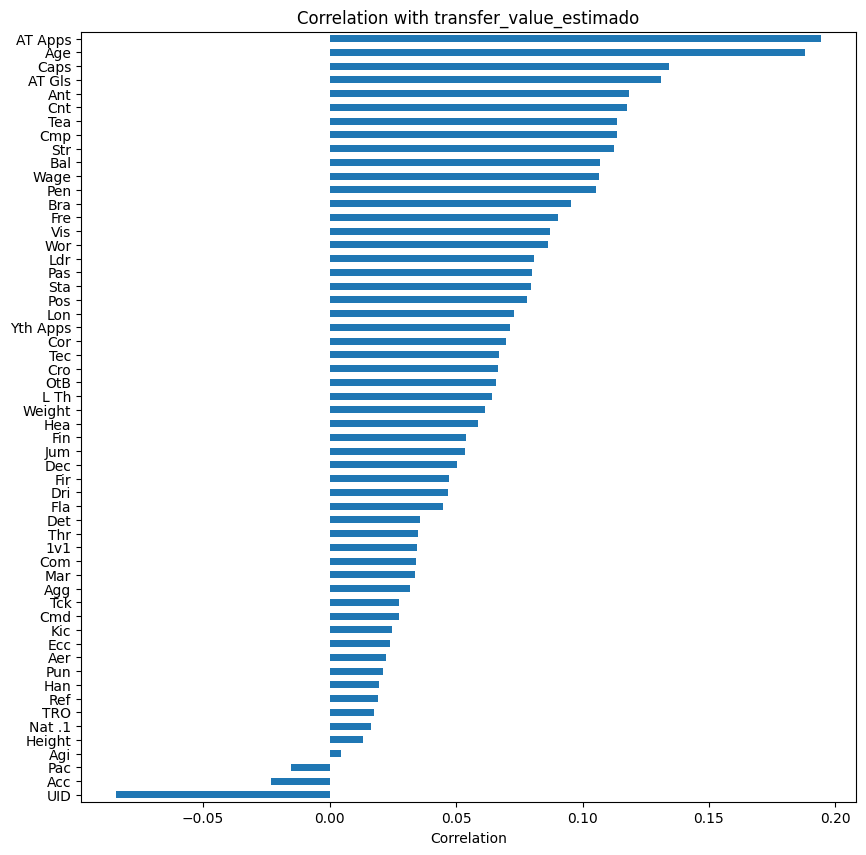

In [159]:
import pandas as pd

target = "transfer_value_estimado"   # <-- change this

# Keep only numeric columns
numeric_df = df.select_dtypes(include="number")

# Compute correlation vector
corr_with_target = (
    numeric_df
        .corr()[target]
        .drop(target)      # remove self-correlation (1.0)
        .sort_values()
)

# corr_abs = corr_with_target.abs().sort_values()
# corr_abs = corr_with_target.abs().sort_values()
plt.figure(figsize=(10, 10))

# plt.figure().set_figheight(1000)
# plt.figure()
corr_with_target.plot(kind="barh")

plt.title(f"Correlation with {target}")
plt.xlabel("Correlation")
# plt.tight_layout()

plt.show()

## EDA con ydata_profiling

In [160]:
# Make the necessary imports
import pandas as pd
from ydata_profiling import ProfileReport
generar=False
if generar:
    # Generate the report
    profile = ProfileReport(df,title="Football manager 2023 Profile")

    # Save the report to .html
    profile.to_file("fm23_report.html")

## Anexo tabla de columnas

In [161]:
import pandas as pd
generar=False
if generar:
    meta = pd.read_csv("atributos_fm_con_explicacion.csv")
    meta["Columna"] = meta["Columna"].str.strip()
    df.columns = df.columns.str.strip()
    meta["Tipo de dato"] = meta["Columna"].map(df.dtypes.astype(str))
    meta.to_csv("tabla_datos.csv", index=False, encoding="utf-8")

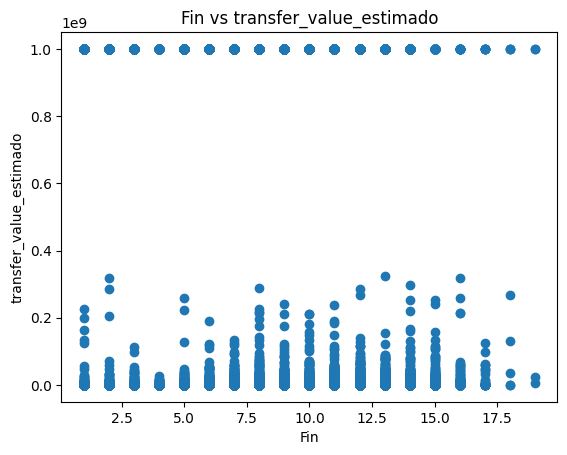

In [162]:
import matplotlib.pyplot as plt
# for col in df.columns:    
    # if col=="transfer_value_estimado" or col=="UID" or col=="Inf":
    #     continue
# df["Fin"]
col="Fin"
plt.figure()
plt.scatter(df[col], df["transfer_value_estimado"])
plt.xlabel(col)
plt.ylabel('transfer_value_estimado')
plt.title(f'{col} vs transfer_value_estimado')
plt.show()
